In [43]:
!pip install pandas numpy scipy liac-arff scikit-learn


[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: pip install --upgrade pip


In [44]:

import arff
import pandas as pd

# Load the ARFF file
with open('sentiment_sentences.arff', 'r') as f:
    arff_data = arff.load(f)

# Convert to a DataFrame
data = arff_data['data']
attributes = [attr[0] for attr in arff_data['attributes']]
df = pd.DataFrame(data, columns=attributes)

# Save as CSV
df.to_csv('sentiment_sentences.csv', index=False)              


In [45]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load the data
data = pd.read_csv('sentiment_sentences.csv')

In [46]:
# Randomize the data
data = data.sample(frac=1).reset_index(drop=True)

# Split the data into cross-validation (2/3) and development (1/3)
train_data, dev_data = train_test_split(data, test_size=1/3, random_state=42)

# Save the split datasets if needed
train_data.to_csv('sentiment_sentences_cross_validation.csv', index=False)
dev_data.to_csv('sentiment_sentences_dev.csv', index=False)

print("Data successfully loaded and split into training and development sets.")

Data successfully loaded and split into training and development sets.


In [47]:
from sklearn.feature_extraction.text import CountVectorizer

# Extract unigram features
vectorizer = CountVectorizer(ngram_range=(1, 1))  # Only unigrams
X_train = vectorizer.fit_transform(train_data['text'])
y_train = train_data['label']

X_dev = vectorizer.transform(dev_data['text'])
y_dev = dev_data['label']

print("Unigram features extracted.")

Unigram features extracted.


In [48]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, cohen_kappa_score

# Train a baseline model with 10-fold cross-validation
model = LinearSVC()
cross_val_scores = cross_val_score(model, X_train, y_train, cv=10)

# Calculate average accuracy
baseline_accuracy = cross_val_scores.mean()
print(f'Baseline Accuracy (10-fold CV): {baseline_accuracy:.2f}')

# Train the model on the cross-validation set and test on the development set
model.fit(X_train, y_train)
y_pred = model.predict(X_dev)

# Calculate accuracy and kappa on development set
dev_accuracy = accuracy_score(y_dev, y_pred)
dev_kappa = cohen_kappa_score(y_dev, y_pred)

print(f'Development Set Accuracy: {dev_accuracy:.2f}')
print(f'Development Set Kappa: {dev_kappa:.2f}')


Baseline Accuracy (10-fold CV): 0.73
Development Set Accuracy: 0.74
Development Set Kappa: 0.49


In [49]:
!pip install seaborn matplotlib


[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: pip install --upgrade pip


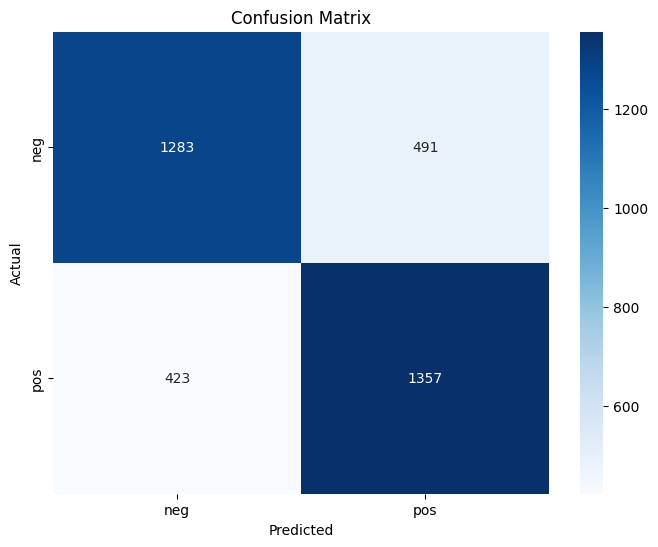

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_dev, y_pred)

# Visualize confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



In [51]:
incorrect = dev_data[(y_dev != y_pred)]  # Instances where the model was wrong
correct = dev_data[(y_dev == y_pred)]    # Instances where the model was right
# Get the feature names (i.e., the unigrams)
feature_names = vectorizer.get_feature_names_out()

# Example: Analyzing a specific incorrect prediction
print("Incorrect instance:", incorrect.iloc[0])
print("Feature importance (Unigrams):", feature_names)


Incorrect instance: label                                                  pos
text     it's a feel-good movie about which you can act...
Name: 4080, dtype: object
Feature importance (Unigrams): ['00' '000' '007' ... 'zucker' 'zwick' 'zzzzzzzzz']


In [52]:
# Get the coefficients (feature weights) from the trained SVM model
feature_weights = model.coef_.flatten()

# Identify the top positive and negative features
top_positive_features = feature_names[np.argsort(feature_weights)[-10:]]
top_negative_features = feature_names[np.argsort(feature_weights)[:10]]

print("Top positive features (indicate positive sentiment):", top_positive_features)
print("Top negative features (indicate negative sentiment):", top_negative_features)


Top positive features (indicate positive sentiment): ['calls' 'tasty' 'crowdpleaser' 'moved' 'moodiness' 'jealousy'
 'resurrection' 'engage' 'buffs' 'liberating']
Top negative features (indicate negative sentiment): ['wasn' '1982' 'bland' 'forgettably' 'unless' 'boldface' 'apparent'
 'choppy' 'lacking' 'wants']


In [53]:
from sklearn.metrics import confusion_matrix

# Confusion matrix to identify misclassified instances
conf_matrix = confusion_matrix(y_dev, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Find misclassified instances
dev_data['predicted_label'] = y_pred
misclassified = dev_data[dev_data['label'] != dev_data['predicted_label']]

print("Number of misclassified examples:", len(misclassified))
print("Examples of misclassified data:")
print(misclassified.head())


Confusion Matrix:
[[1283  491]
 [ 423 1357]]
Number of misclassified examples: 914
Examples of misclassified data:
     label                                               text predicted_label
4080   pos  it's a feel-good movie about which you can act...             neg
582    neg  a movie that harps on media-constructed 'issue...             pos
4111   pos  moonlight mile gives itself the freedom to fee...             neg
304    neg                 simplistic fluff-ball of whimsy .              pos
533    pos  sweet home alabama  is what it is � a nice , h...             neg


In [56]:
# Investigating specific cases where the model misclassifies
for i, row in incorrect.iterrows():
    print(f"Misclassified instance #{i}:")
    print("Text:", row['text'])
    print("Actual label:", row['label'])
    
    # Access the corresponding prediction using .iloc
    print("Predicted label:", y_pred[incorrect.index.get_loc(i)])
    print()


Misclassified instance #4080:
Text: it's a feel-good movie about which you can actually feel good . 
Actual label: pos
Predicted label: pos

Misclassified instance #582:
Text: a movie that harps on media-constructed 'issues' like whether compromise is the death of self� this orgasm [won't be an] exceedingly memorable one for most people . 
Actual label: neg
Predicted label: pos

Misclassified instance #4111:
Text: moonlight mile gives itself the freedom to feel contradictory things . it is sentimental but feels free to offend , is analytical and then surrenders to the illogic of its characters , is about grief and yet permits laughter . 
Actual label: pos
Predicted label: neg

Misclassified instance #304:
Text: simplistic fluff-ball of whimsy . 
Actual label: neg
Predicted label: pos

Misclassified instance #533:
Text: sweet home alabama  is what it is � a nice , harmless date film . . . 
Actual label: pos
Predicted label: pos

Misclassified instance #6978:
Text: short and sweet , but 

In [57]:
from sklearn.feature_extraction.text import CountVectorizer
import re

# Function to handle negations (simple replacement of common negations)
def handle_negations(text):
    text = re.sub(r"(?<!\w)(not|no|never|n't)\s+", "NEG_", text)
    return text

# Apply negation handling to both training and development data
train_data['text'] = train_data['text'].apply(handle_negations)
dev_data['text'] = dev_data['text'].apply(handle_negations)

# Feature extraction with both unigrams and bigrams
vectorizer = CountVectorizer(ngram_range=(1, 2))  # Unigrams and Bigrams
X_train = vectorizer.fit_transform(train_data['text'])
y_train = train_data['label']

X_dev = vectorizer.transform(dev_data['text'])
y_dev = dev_data['label']

print("Unigram and bigram features with negation handling extracted.")


Unigram and bigram features with negation handling extracted.


In [58]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, cohen_kappa_score

# Re-train with the new feature set using 10-fold cross-validation
model = LinearSVC()
cross_val_scores = cross_val_score(model, X_train, y_train, cv=10)

# Record the new baseline accuracy
new_baseline_accuracy = cross_val_scores.mean()
print(f'New Baseline Accuracy (10-fold CV) with Bigrams and Negation Handling: {new_baseline_accuracy:.2f}')

# Train on the cross-validation set and test on the development set
model.fit(X_train, y_train)
y_pred = model.predict(X_dev)

# Calculate accuracy and kappa on the development set
new_dev_accuracy = accuracy_score(y_dev, y_pred)
new_dev_kappa = cohen_kappa_score(y_dev, y_pred)

print(f'New Development Set Accuracy: {new_dev_accuracy:.2f}')
print(f'New Development Set Kappa: {new_dev_kappa:.2f}')


New Baseline Accuracy (10-fold CV) with Bigrams and Negation Handling: 0.76
New Development Set Accuracy: 0.76
New Development Set Kappa: 0.53


In [30]:
# Extract unigram and bigram features
vectorizer = CountVectorizer(ngram_range=(1, 2))  # Unigrams and bigrams
X_train = vectorizer.fit_transform(train_data['text'])
X_dev = vectorizer.transform(dev_data['text'])

print("Unigram and bigram features extracted.")


Unigram and bigram features extracted.


In [31]:
# Train the improved model
model = LinearSVC()
cross_val_scores = cross_val_score(model, X_train, y_train, cv=10)

# Calculate new average accuracy
improved_accuracy = cross_val_scores.mean()
print(f'Improved Model Accuracy (10-fold CV): {improved_accuracy:.2f}')

# Train and test on the development set
model.fit(X_train, y_train)
y_pred = model.predict(X_dev)

# Calculate accuracy and kappa on development set
dev_accuracy = accuracy_score(y_dev, y_pred)
dev_kappa = cohen_kappa_score(y_dev, y_pred)

print(f'Improved Development Set Accuracy: {dev_accuracy:.2f}')
print(f'Improved Development Set Kappa: {dev_kappa:.2f}')


Improved Model Accuracy (10-fold CV): 0.76
Improved Development Set Accuracy: 0.76
Improved Development Set Kappa: 0.52


In [32]:
print(f'Baseline Accuracy: {baseline_accuracy:.2f}')
print(f'Improved Accuracy: {improved_accuracy:.2f}')

if improved_accuracy > baseline_accuracy:
    print("The improved model performs better than the baseline.")
else:
    print("The baseline model still performs better.")


Baseline Accuracy: 0.74
Improved Accuracy: 0.76
The improved model performs better than the baseline.


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, cohen_kappa_score

# Re-train with the new feature set using 10-fold cross-validation
model = LinearSVC()
cross_val_scores = cross_val_score(model, X_train, y_train, cv=10)

# Record the new baseline accuracy
new_baseline_accuracy = cross_val_scores.mean()
print(f'New Baseline Accuracy (10-fold CV) with Bigrams and Negation Handling: {new_baseline_accuracy:.2f}')

# Train on the cross-validation set and test on the development set
model.fit(X_train, y_train)
y_pred = model.predict(X_dev)

# Calculate accuracy and kappa on the development set
new_dev_accuracy = accuracy_score(y_dev, y_pred)
new_dev_kappa = cohen_kappa_score(y_dev, y_pred)

print(f'New Development Set Accuracy: {new_dev_accuracy:.2f}')
print(f'New Development Set Kappa: {new_dev_kappa:.2f}')


New Baseline Accuracy (10-fold CV) with Bigrams and Negation Handling: 0.76
New Development Set Accuracy: 0.76
New Development Set Kappa: 0.53


In [61]:
from scipy import stats

# Baseline cross-validation accuracies
baseline_accuracies = cross_val_scores

# Improved cross-validation accuracies
improved_accuracies = cross_val_scores_with_bigrams

# Perform paired t-test
t_stat, p_value = stats.ttest_rel(improved_accuracies, baseline_accuracies)

# Check if the difference is statistically significant
if p_value < 0.05:
    print("The performance improvement is statistically significant (p < 0.05).")
else:
    print("The performance improvement is not statistically significant (p >= 0.05).")


NameError: name 'cross_val_scores_with_bigrams' is not defined